### **Imports**

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
import numpy as np
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy import sparse
from typing import Optional, Set, Tuple, Any, Dict, List

### **Load data**

#### IMDB dataset

In [25]:
file_path = "data/imdb/IMDB_Dataset.csv"
df = pd.read_csv(file_path)

In [26]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### **Task 1**

#### Data exploration

In [27]:
def analyze_class_distribution(df: pd.DataFrame, target_column: str) -> None:
    """
    Analyzes and prints the distribution of the target class.

    Args:
        df (pd.DataFrame): The dataset containing the target column.
        target_column (str): The name of the column representing the class labels.
    """

    counts = df[target_column].value_counts()
    percentage = df[target_column].value_counts(normalize=True) * 100

    print("\nClass Distribution")
    print(counts)
    print("\nClass Percentage")
    print(percentage)

    # Visualization
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_column, data=df)
    plt.title('Distribution of Sentiment Classes')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.show()

In [28]:
def analyze_text_length(
    df: pd.DataFrame, 
    text_column: str, 
    target_column: Optional[str] = None
) -> None:
    """
    Calculates text length statistics and visualizes the distribution.
    If a target column is provided, it also compares text length across classes.

    Args:
        df (pd.DataFrame): The dataset containing the text.
        text_column (str): The name of the column containing text data.
        target_column (Optional[str]): The name of the target class column. 
                                       If provided, a boxplot by class is generated.
    """

    # Create a new column for text length (number of words)
    length_col_name = 'text_length'
    df[length_col_name] = df[text_column].apply(lambda x: len(str(x).split()))

    print("\nText Length Statistics (Word Count)")
    print(df[length_col_name].describe())
    
    if target_column and target_column in df.columns:
        print(f"\nText Length Statistics by Class ({target_column})")
        print(df.groupby(target_column)[length_col_name].describe())

    # Visualization Setup
    if target_column:
        # Boxplot by Class
        # This creates side-by-side vertical boxplots for each class
        sns.boxplot(x=target_column, y=length_col_name, data=df, hue=target_column, palette="Set2", legend=False)
        plt.title('Review Length by Sentiment')
        plt.xlabel('Sentiment')
        plt.ylabel('Number of Words')
        plt.tight_layout()
        plt.show()
        
    else:
        # Fallback if no target column provided (just the histogram)
        plt.figure(figsize=(10, 6))
        sns.histplot(df[length_col_name], bins=50, kde=False)
        plt.title('Distribution of Review Lengths')
        plt.xlabel('Number of Words')
        plt.ylabel('Frequency')
        max_val = df[length_col_name].max()
        ticks = np.arange(0, max_val + 100, 100)
        plt.xticks(ticks)
        plt.xticks(rotation=45)
        plt.show()

In [29]:
TEXT_COL = 'review'
TARGET_COL = 'sentiment'

# Basic Exploration
print("\nDataset Info")
print(f"Shape: {df.shape}")
print(df.info())


Dataset Info
Shape: (50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None



Class Distribution
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Class Percentage
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


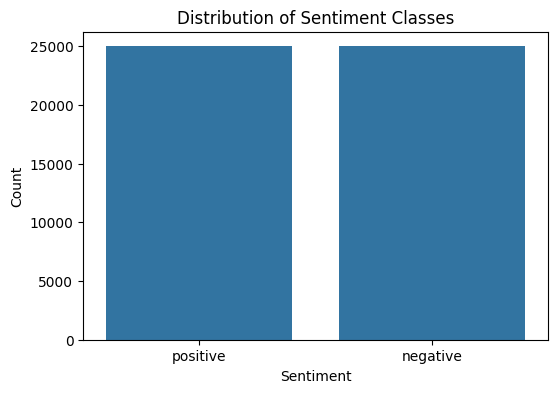

In [30]:
# Class Distribution
analyze_class_distribution(df, TARGET_COL)


Text Length Statistics (Word Count)
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: text_length, dtype: float64


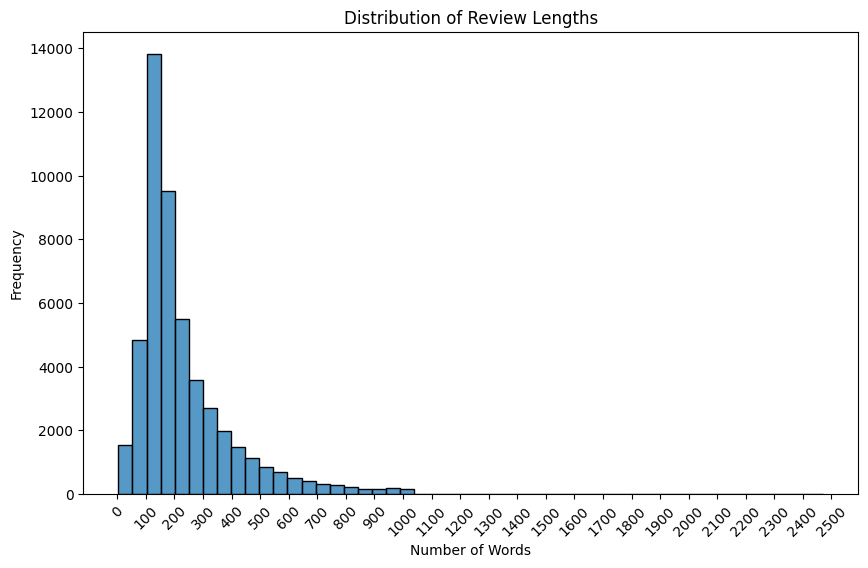

In [31]:
# Text Length Analysis
analyze_text_length(df, TEXT_COL)


Text Length Statistics (Word Count)
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: text_length, dtype: float64

Text Length Statistics by Class (sentiment)
             count       mean         std   min    25%    50%    75%     max
sentiment                                                                   
negative   25000.0  229.46456  164.947795   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.84932  177.497046  10.0  125.0  172.0  284.0  2470.0


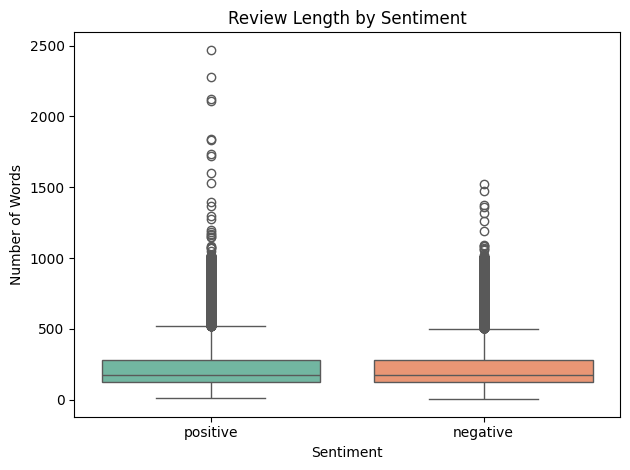

In [32]:
analyze_text_length(df, text_column='review', target_column='sentiment')

#### **Conclusions**: <br> 1. No Correlation with Sentiment: There is no statistically significant difference in review length between positive and negative classes, although there are more especially long outliers in the positive reviews. <br> 2. Right-Skewed Distribution: The mean (~231) is noticeably higher than the median (~173) for the entire dataset. This indicates a right-skewed distribution where a small number of extremely long reviews pull the average up.<br>3. Outliers and Truncation: While the longest review is 2,470 words, 75% of all reviews are under 280 words.

### **Task 2**

#### Data preparation

In [33]:
# Ensure necessary NLTK data is downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading NLTK stopwords.")
    nltk.download('stopwords')

In [34]:
def get_stopwords() -> Set[str]:
    """
    Retrieves the set of English stopwords from NLTK.
    
    Returns:
        Set[str]: A set of unique stopwords.
    """
    return set(stopwords.words('english'))

def clean_text(text: str, stop_words: Set[str]) -> str:
    """
    Performs text preprocessing:
    1. Converts text to lowercase.
    2. Removes numbers.
    3. Removes punctuation.
    4. Removes stopwords.

    Args:
        text (str): The raw input text.
        stop_words (Set[str]): A set of words to be removed.

    Returns:
        str: The cleaned and preprocessed text.
    """
    if not isinstance(text, str):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    # Using regex to replace digits with an empty string
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    # We use translation table to remove all punctuation marks efficiently
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove stopwords
    # Split text into words (simple tokenization by whitespace)
    words = text.split()
    # Filter out stopwords
    cleaned_words = [word for word in words if word not in stop_words]

    # Join the words back into a single string
    return " ".join(cleaned_words)

In [35]:
def apply_preprocessing(df: pd.DataFrame, text_column: str) -> pd.DataFrame:
    """
    Applies the cleaning function to the specified text column.

    Args:
        df (pd.DataFrame): Input DataFrame.
        text_column (str): Name of the column to process.

    Returns:
        pd.DataFrame: DataFrame with a new column 'cleaned_text'.
    """
    if text_column not in df.columns:
        print(f"Error: Column '{text_column}' not found.")
        return df

    english_stopwords = get_stopwords()
    # Create a new column to preserve original data
    df['cleaned_text'] = df[text_column].apply(lambda x: clean_text(str(x), english_stopwords))
    
    print("Preprocessing complete.")
    return df

In [36]:
df = apply_preprocessing(df, 'review')
print(df[['review', 'cleaned_text']].head())

Preprocessing complete.
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        cleaned_text  
0  one reviewers mentioned watching oz episode yo...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically theres family little boy jake thinks...  
4  petter matteis love time money visually stunni...  


### **Task 3**

#### Text vectorization

In [37]:
def perform_tfidf_vectorization(
    df: pd.DataFrame, 
    text_column: str, 
    max_features: int = 5000
) -> Tuple[sparse.csr_matrix, Any]:
    """
    Transforms text data into TF-IDF features using sklearn's TfidfVectorizer.

    Args:
        df (pd.DataFrame): The dataframe containing the cleaned text.
        text_column (str): The name of the column with preprocessed text.
        max_features (int): The maximum number of features (vocabulary size) to keep. 
                            Limits the dimensionality of the resulting matrix.

    Returns:
        Tuple[sparse.csr_matrix, Any]: 
            - The feature matrix (X) in sparse format.
            - The fitted vectorizer object (useful for transforming future data).
    """
    if text_column not in df.columns:
        raise ValueError(f"Column '{text_column}' not found in DataFrame.")

    print(f"Vectorizing column '{text_column}' using TF-IDF...")
    print(f"Max features limited to: {max_features}")

    # Initialize TfidfVectorizer
    # We restrict max_features to avoid memory issues and reduce noise from very rare words
    vectorizer = TfidfVectorizer(max_features=max_features)

    # Fit and transform the data
    # fit: learns the vocabulary
    # transform: creates the document-term matrix
    tfidf_matrix = vectorizer.fit_transform(df[text_column])

    print("Vectorization complete.")
    print(f"Matrix shape: {tfidf_matrix.shape}")
    
    return tfidf_matrix, vectorizer

In [38]:
X, vectorizer = perform_tfidf_vectorization(df, 'cleaned_text', max_features=5000)
print(vectorizer.get_feature_names_out()[:20])

Vectorizing column 'cleaned_text' using TF-IDF...
Max features limited to: 5000
Vectorization complete.
Matrix shape: (50000, 5000)
['aaron' 'abandoned' 'abc' 'abilities' 'ability' 'able' 'absence' 'absent'
 'absolute' 'absolutely' 'absurd' 'abuse' 'abused' 'abusive' 'abysmal'
 'academy' 'accent' 'accents' 'accept' 'acceptable']


### **Task 4** and **Task 5**

#### Classification model

In [39]:
def encode_targets(df: pd.DataFrame, target_column: str) -> Tuple[np.ndarray, LabelEncoder]:
    """
    Encodes target labels (e.g., 'positive', 'negative') into integers.

    Args:
        df (pd.DataFrame): DataFrame containing the target column.
        target_column (str): Name of the target column.

    Returns:
        Tuple[np.ndarray, LabelEncoder]: 
            - Array of encoded labels (y).
            - The fitted LabelEncoder object (to reverse transform if needed).
    """
    if target_column not in df.columns:
        raise ValueError(f"Column '{target_column}' not found.")

    le = LabelEncoder()
    y = le.fit_transform(df[target_column])
    
    print(f"Labels encoded. Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    return y, le

In [40]:
def train_and_evaluate(
    X: sparse.csr_matrix, 
    y: np.ndarray, 
    model_type: str = 'logreg',
    test_size: float = 0.2,
    random_state: int = 42
) -> Any:
    """
    Splits data, trains the specified model, and prints evaluation metrics.

    Args:
        X (sparse.csr_matrix): Feature matrix (TF-IDF).
        y (np.ndarray): Target vector (labels).
        model_type (str): 'logreg' for Logistic Regression or 'bayes' for Naive Bayes.
        test_size (float): Proportion of the dataset to include in the test split.
        random_state (int): Seed for reproducibility.

    Returns:
        Any: The trained model object.
    """
    # 1. Split the data
    # Stratify=y ensures that the proportion of positive/negative is the same in train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"\nTraining Model: {model_type.upper()}")
    print(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

    # 2. Initialize the model
    if model_type == 'logreg':
        model = LogisticRegression(max_iter=1000, random_state=random_state)
    elif model_type == 'bayes':
        model = MultinomialNB()
    else:
        raise ValueError("Invalid model_type. Choose 'logreg' or 'bayes'.")

    # 3. Train (Fit)
    model.fit(X_train, y_train)

    # 4. Predict
    y_pred = model.predict(X_test)

    # 5. Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return model, y_test, y_pred

In [41]:
def plot_confusion_matrix(
    y_true: np.ndarray, 
    y_pred: np.ndarray, 
    class_names: List[str],
    title: str = "Confusion Matrix"
) -> None:
    """
    Generates and plots a heatmap of the confusion matrix.

    Args:
        y_true (np.ndarray): The actual true labels.
        y_pred (np.ndarray): The predicted labels by the model.
        class_names (List[str]): List of class names (e.g., ['Negative', 'Positive']).
        title (str): Title of the plot.
    """
    # Calculate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Visualization
    plt.figure(figsize=(8, 6))
    
    # Create a heatmap
    # annot=True: write the data value in each cell
    # fmt='d': format as integers (decimal)
    # cmap='Blues': color map
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)

    plt.title(title)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

Labels encoded. Mapping: {'negative': np.int64(0), 'positive': np.int64(1)}

Training Model: LOGREG
Train set size: 40000, Test set size: 10000

Accuracy: 0.8886

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



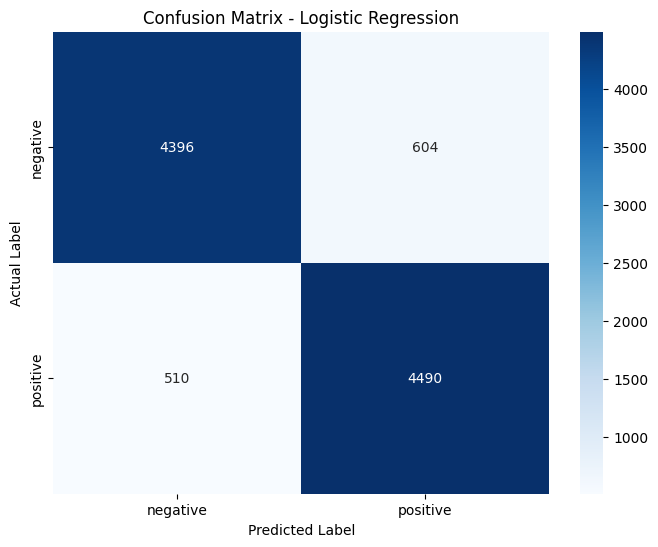


Training Model: BAYES
Train set size: 40000, Test set size: 10000

Accuracy: 0.8543

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      5000
           1       0.85      0.86      0.86      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



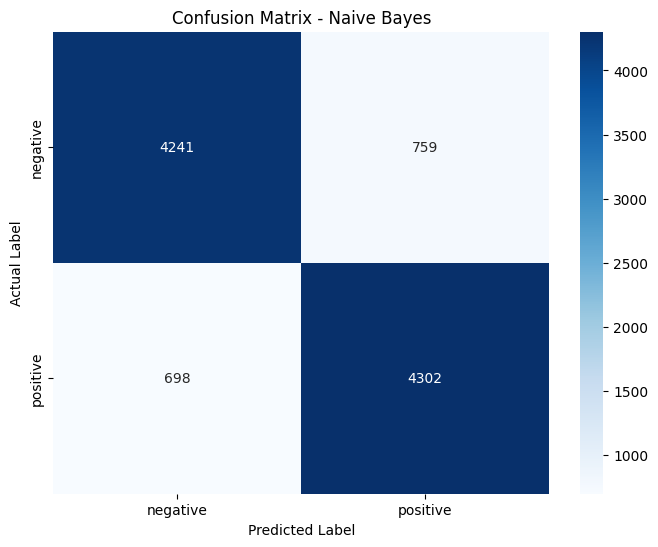

In [42]:
# Prepare Target
y, label_encoder = encode_targets(df, 'sentiment')
class_names = label_encoder.classes_

# Model 1: Logistic Regression
# Unpack the returned tuple: model, true labels, and predictions
logreg_model, y_test_lr, y_pred_lr = train_and_evaluate(X, y, model_type='logreg')

# Plot Confusion Matrix for Logistic Regression
plot_confusion_matrix(
    y_test_lr, 
    y_pred_lr, 
    class_names, 
    title="Confusion Matrix - Logistic Regression"
)

# Model 2: Naive Bayes
# Unpack the returned tuple again
nb_model, y_test_nb, y_pred_nb = train_and_evaluate(X, y, model_type='bayes')

# Plot Confusion Matrix for Naive Bayes
plot_confusion_matrix(
    y_test_nb, 
    y_pred_nb, 
    class_names, 
    title="Confusion Matrix - Naive Bayes"
)

#### **Model Performance Analysis** <br>Based on the evaluation metrics on the test set (10,000 samples), we can draw the following conclusions:<br>1. Logistic Regression achieved higher accuracy, outperforming the Naive Bayes model.<br>2. Balanced Predictions: Both models demonstrate a balanced performance between classes. The F1-scores for negative (0) and positive (1) reviews are nearly identical, indicating the models do not suffer from significant bias toward either sentiment.<br>3. Quality: Achieving ~89% accuracy is a decent result.

### **Task 6**

#### Prediction on new data

In [ ]:
def predict_new_reviews(
    reviews: List[str], 
    model: Any, 
    vectorizer: Any, 
    stop_words: Set[str]
) -> pd.DataFrame:
    """
    Preprocesses new raw reviews, transforms them using the fitted vectorizer,
    and predicts sentiment using the trained model.

    Args:
        reviews (List[str]): A list of raw text reviews.
        model (Any): The trained classification model (e.g., LogisticRegression).
        vectorizer (Any): The fitted TfidfVectorizer.
        stop_words (Set[str]): Set of stopwords used during training.

    Returns:
        pd.DataFrame: A dataframe showing the text, predicted label, and probability.
    """
    results = []

    print(f"Processing {len(reviews)} new reviews.")

    for text in reviews:
        # Clean the text (Using the function from Task 2)
        cleaned = clean_text(text, stop_words)
        
        # Vectorize
        # We must map the new words to the existing vocabulary ID
        text_vector = vectorizer.transform([cleaned])
        
        # Predict Class
        prediction = model.predict(text_vector)[0]
        
        # Predict Probability (Confidence)
        # This helps us see how "sure" the model is
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(text_vector)[0]
            # proba[1] is the probability of the positive class
            confidence = proba[1] 
        else:
            confidence = np.nan

        # Map 0/1 to readable labels
        label = "Positive" if prediction == 1 else "Negative"

        results.append({
            "Original Text": text,
            "Cleaned Text": cleaned,
            "Prediction": label,
            "Positive_Probability": f"{confidence:.4f}" if confidence is not np.nan else "N/A"
        })

    return pd.DataFrame(results)

In [44]:
# Create custom reviews
rev1 = "I loved it! Ron Swanson is so funny!" # Positive
rev2 = "What a waste of time and money. I did not laugh even once." # Negative
rev3 = "I can't say anything especially negative nor positive about this movie. It was nice, just average." # Neutral
ok_review = "okay" #just the word okay
reviews = [rev1, rev2, rev3, ok_review]
reviews

['I loved it! Ron Swanson is so funny!',
 'What a waste of time and money. I did not laugh even once.',
 "I can't say anything especially negative nor positive about this movie. It was nice, just average.",
 'okay']

In [45]:
# Get stopwords
english_stopwords = get_stopwords()
# Logistic Regression model
results_logreg_df = predict_new_reviews(reviews, logreg_model, vectorizer, english_stopwords)
display(results_logreg_df)

Processing 4 new reviews.


,Original Text,Cleaned Text,Prediction,Positive_Probability
0,I loved it! Ron Swanson is so funny!,loved ron swanson funny,Positive,0.8883
1,What a waste of time and money. I did not laug...,waste time money laugh even,Negative,0.0016
2,I can't say anything especially negative nor p...,cant say anything especially negative positive...,Negative,0.4293
3,okay,okay,Negative,0.1132


In [46]:
# Naive Bayes model
results_nb_df = predict_new_reviews(reviews, nb_model, vectorizer, english_stopwords)
display(results_nb_df)

Processing 4 new reviews.


,Original Text,Cleaned Text,Prediction,Positive_Probability
0,I loved it! Ron Swanson is so funny!,loved ron swanson funny,Positive,0.6240
1,What a waste of time and money. I did not laug...,waste time money laugh even,Negative,0.0845
2,I can't say anything especially negative nor p...,cant say anything especially negative positive...,Negative,0.3956
3,okay,okay,Negative,0.3070


#### **Conclusions**: Both models correctly classified clearly positive and negative reviews. In these cases, logistic regression model showed greater certainty in its classification assessment. Interestingly, both models, forced into binary classification, assessed a relatively neutral review as negative. The last experiment, which involved assessing the sentiment of the word “okay,” showed also that both models assigned it to the negative class.